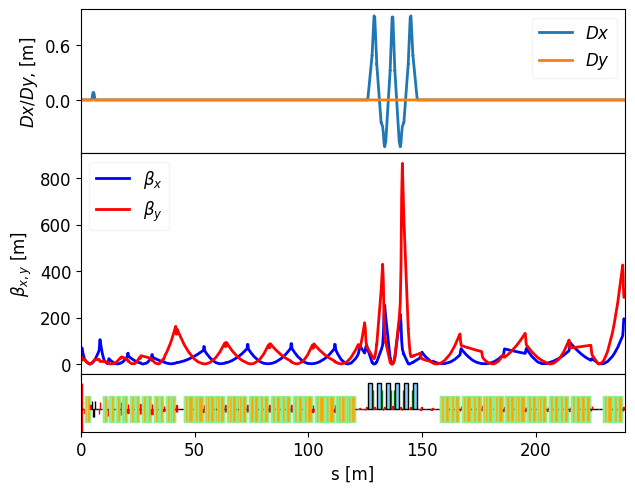

In [ ]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt


from PSECTA import *


lat = MagneticLattice(lattice_list)



##### PA1RFGUN #####
AX =-21.12   
BX =24.36 
AY =-21.16     
BY =24.42      
EMITX =1.2023504614117648e-06
EMITY =1.2023504614117648e-06 
DP =.01
##### PA1RFGUN #####

energy = 0.0091 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])

In [272]:
start_index = next(i for i, el in enumerate(lattice_list) if el.id == "PA1RFGUN")
end_index = next(i for i, el in enumerate(lattice_list) if el.id == "L491")

sub_lat = MagneticLattice(lattice_list[start_index:end_index + 1])

R = lattice_transfer_map(sub_lat, energy=1.5)
print("R56 = ", R[4,5]*1000, "mm")


R56 =  -23.38775880448409 mm


In [ ]:
def gauss_from_twiss_vec(emit, beta, alpha, size=1):
    phi = 2 * np.pi * np.random.rand(size)
    u = np.random.rand(size)
    a = np.sqrt(-2 * np.log(1 - u) * emit)
    x = a * np.sqrt(beta) * np.cos(phi)
    xp = -a / np.sqrt(beta) * (np.sin(phi) + alpha * np.cos(phi))
    return x, xp

nparticles = 100000
p_array = ParticleArray(n=nparticles)

sigma_tau = 6.7e-3  # (bunch length in time)
sigma_p = 5.e-4     # relative momentum spread (Δp/p)  

p_array.E = energy  # GeV

# Longitudinal
p_array.rparticles[4] = np.random.randn(nparticles) * sigma_tau
p_array.rparticles[5] = np.random.randn(nparticles) * sigma_p

# Transverse: vectorized sampling from Twiss parameters
x, xp = gauss_from_twiss_vec(tw0.emit_x, tw0.beta_x, tw0.alpha_x, size=nparticles)
y, yp = gauss_from_twiss_vec(tw0.emit_y, tw0.beta_y, tw0.alpha_y, size=nparticles)

p_array.rparticles[0] = x
p_array.rparticles[1] = xp
p_array.rparticles[2] = y
p_array.rparticles[3] = yp

# Charge distribution
charge = 4.0e-9  # nC
p_array.q_array = np.ones(nparticles) * (charge / nparticles)




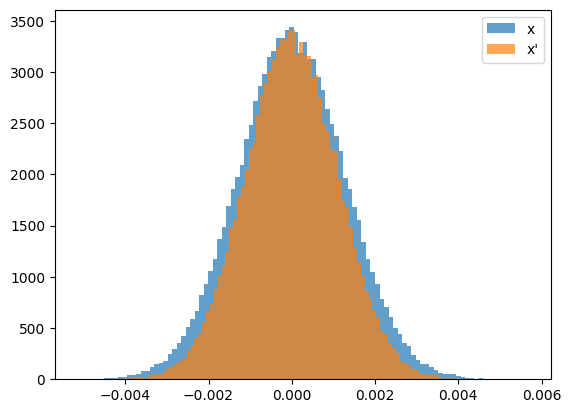

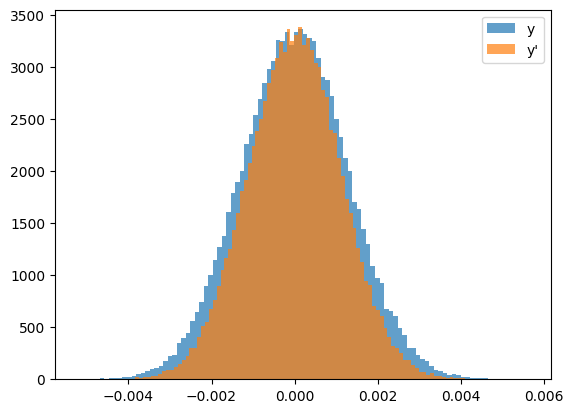

In [274]:


plt.hist(p_array.rparticles[0], bins=100, alpha=0.7, label='x')
plt.hist(p_array.rparticles[1], bins=100, alpha=0.7, label="x'")
plt.legend()
plt.show()

plt.hist(p_array.rparticles[2], bins=100, alpha=0.7, label='y')
plt.hist(p_array.rparticles[3], bins=100, alpha=0.7, label="y'")
plt.legend()
plt.show()


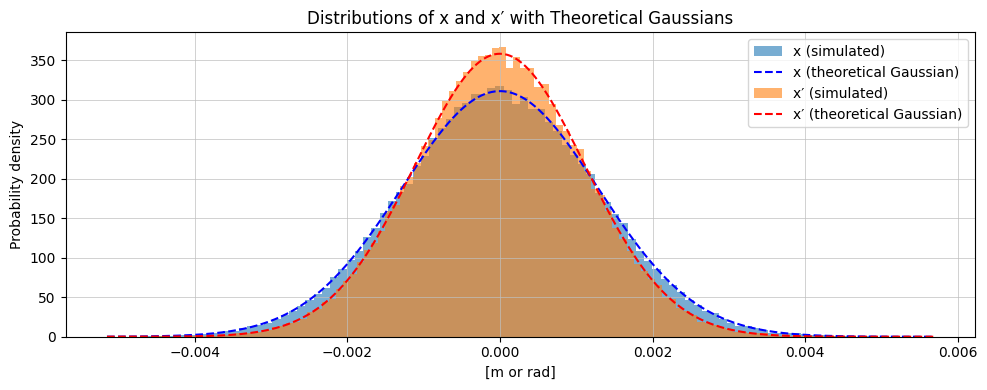

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Get simulated data
x = p_array.rparticles[0]
xp = p_array.rparticles[1]

# Get theoretical σ values
def twiss_sigmas(emit, beta, alpha):
    gamma = (1 + alpha**2) / beta
    return np.sqrt(beta * emit), np.sqrt(gamma * emit)

sigma_x, sigma_xp = twiss_sigmas(tw0.emit_x, tw0.beta_x, tw0.alpha_x)

# Define histogram range
bins = 100
x_range = np.linspace(min(x.min(), xp.min()), max(x.max(), xp.max()), 1000)

# Plot x
plt.figure(figsize=(10, 4))
plt.hist(x, bins=bins, density=True, alpha=0.6, label='x (simulated)')
plt.plot(x_range, norm.pdf(x_range, 0, sigma_x), 'b--', label='x (theoretical Gaussian)')

# Plot x'
plt.hist(xp, bins=bins, density=True, alpha=0.6, label="x′ (simulated)")
plt.plot(x_range, norm.pdf(x_range, 0, sigma_xp), 'r--', label="x′ (theoretical Gaussian)")

plt.xlabel('[m or rad]')
plt.ylabel('Probability density')
plt.title("Distributions of x and x′ with Theoretical Gaussians")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


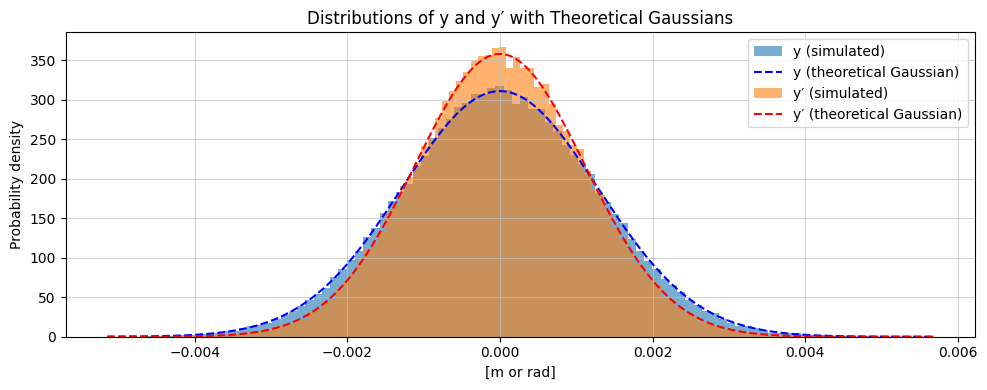

In [276]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Get simulated data
y = p_array.rparticles[2]
yp = p_array.rparticles[3]

# Get theoretical σ values
def twiss_sigmas(emit, beta, alpha):
    gamma = (1 + alpha**2) / beta
    return np.sqrt(beta * emit), np.sqrt(gamma * emit)

sigma_y, sigma_yp = twiss_sigmas(tw0.emit_y, tw0.beta_y, tw0.alpha_y)

# Define histogram range
bins = 100
x_range = np.linspace(min(x.min(), xp.min()), max(x.max(), xp.max()), 1000)

# Plot x
plt.figure(figsize=(10, 4))
plt.hist(x, bins=bins, density=True, alpha=0.6, label='y (simulated)')
plt.plot(x_range, norm.pdf(x_range, 0, sigma_x), 'b--', label='y (theoretical Gaussian)')

# Plot x'
plt.hist(xp, bins=bins, density=True, alpha=0.6, label="y′ (simulated)")
plt.plot(x_range, norm.pdf(x_range, 0, sigma_yp), 'r--', label="y′ (theoretical Gaussian)")

plt.xlabel('[m or rad]')
plt.ylabel('Probability density')
plt.title("Distributions of y and y′ with Theoretical Gaussians")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [277]:
def check_beam_stats(p_array, twiss, axis_label="x"):
    idx = 0 if axis_label == "x" else 2
    idxp = 1 if axis_label == "x" else 3

    sigma = np.std(p_array.rparticles[idx])
    sigmap = np.std(p_array.rparticles[idxp])

    beta = getattr(twiss, f"beta_{axis_label}")
    alpha = getattr(twiss, f"alpha_{axis_label}")
    emit = getattr(twiss, f"emit_{axis_label}")

    sigma_theo = np.sqrt(beta * emit)
    gamma = (1 + alpha**2) / beta
    sigmap_theo = np.sqrt(gamma * emit)

    print(f"σ_{axis_label} (simulated):     {sigma}")
    print(f"σ_{axis_label} (theoretical):   {sigma_theo}")
    print(f"σ_{axis_label}' (simulated):    {sigmap}")
    print(f"σ_{axis_label}' (theoretical):  {sigmap_theo}")


In [278]:
check_beam_stats(p_array, tw0, axis_label="x")


σ_x (simulated):     0.0012801290483762599
σ_x (theoretical):   0.001282460309333141
σ_x' (simulated):    0.0011111985768642758
σ_x' (theoretical):  0.0011131324306998926


In [279]:
check_beam_stats(p_array, tw0, axis_label="y")



σ_y (simulated):     0.0012886113586607019
σ_y (theoretical):   0.001284038722618926
σ_y' (simulated):    0.0011179198783284135
σ_y' (theoretical):  0.0011138650134345758


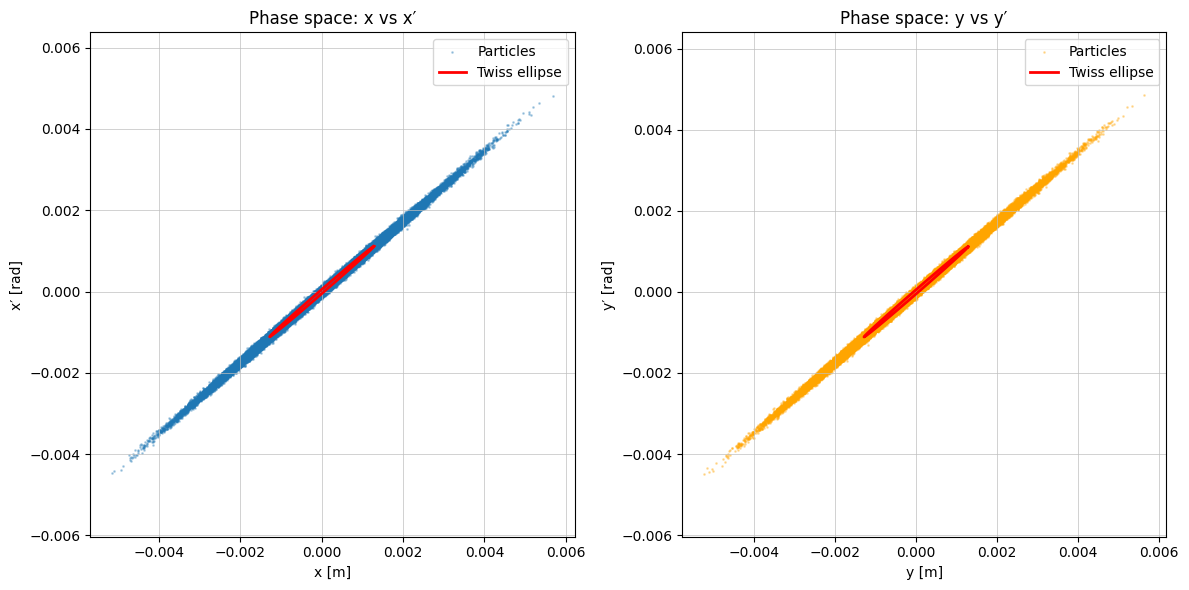

In [280]:
import matplotlib.pyplot as plt
import numpy as np

# --- X plane ---
x = p_array.rparticles[0]
xp = p_array.rparticles[1]
emit_x = tw0.emit_x
beta_x = tw0.beta_x
alpha_x = tw0.alpha_x

theta = np.linspace(0, 2*np.pi, 400)
x_ellipse = np.sqrt(emit_x * beta_x) * np.cos(theta)
xp_ellipse = (-alpha_x * np.cos(theta) + np.sin(theta)) * np.sqrt(emit_x / beta_x)

# --- Y plane ---
y = p_array.rparticles[2]
yp = p_array.rparticles[3]
emit_y = tw0.emit_y
beta_y = tw0.beta_y
alpha_y = tw0.alpha_y

y_ellipse = np.sqrt(emit_y * beta_y) * np.cos(theta)
yp_ellipse = (-alpha_y * np.cos(theta) + np.sin(theta)) * np.sqrt(emit_y / beta_y)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# x-x'
axes[0].scatter(x, xp, s=1, alpha=0.3, label='Particles')
axes[0].plot(x_ellipse, xp_ellipse, 'r', linewidth=2, label='Twiss ellipse')
axes[0].set_xlabel('x [m]')
axes[0].set_ylabel("x′ [rad]")
axes[0].set_title('Phase space: x vs x′')
axes[0].grid(True)
axes[0].axis('equal')
axes[0].legend()

# y-y'
axes[1].scatter(y, yp, s=1, alpha=0.3, color='orange', label='Particles')
axes[1].plot(y_ellipse, yp_ellipse, 'r', linewidth=2, label='Twiss ellipse')
axes[1].set_xlabel('y [m]')
axes[1].set_ylabel("y′ [rad]")
axes[1].set_title('Phase space: y vs y′')
axes[1].grid(True)
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()




In [281]:
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

def plot_emittances_vs_s(p_array, nparts_in_slice=5000, smooth_param=0.05,
                         tau_units="m", inverse_tau=False, grid=True,
                         title="Normalized Emittances vs s", figsize=(8, 4),
                         filename=None):
    """
    Plot normalized emittances vs longitudinal position s (head-tail slicing).

    :param p_array: ParticleArray object
    :param nparts_in_slice: number of particles per slice
    :param smooth_param: smoothing parameter used in slice analysis
    :param tau_units: 'm', 'mm', or 'um'
    :param inverse_tau: flip the tau axis
    :param grid: show grid
    :param title: plot title
    :param figsize: matplotlib figsize
    :param filename: optional path to save the plot
    """
    # Set scale for s-axis
    tau_factors = {"m": 1, "mm": 1e3, "um": 1e6}
    tau_factor = tau_factors.get(tau_units, 1e3)
    tau_label = f"$s\,[\\mathrm{{{tau_units}}}]$"

    # Deepcopy to preserve original
    p_array_copy = deepcopy(p_array)
    if inverse_tau:
        p_array_copy.tau()[:] *= -1

    # Perform slice analysis (assumes this function exists in your codebase)
    slice_params = global_slice_analysis(p_array_copy, nparts_in_slice, smooth_param)

    # Extract and convert to proper units
    s = slice_params.s * tau_factor
    emit_x = slice_params.exn * 1e6  # [mm·mrad]
    emit_y = slice_params.eyn * 1e6

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(s, emit_x, label=r"$\varepsilon_x$", color='red')
    plt.plot(s, emit_y, label=r"$\varepsilon_y$", color='blue')
    plt.xlabel(tau_label)
    plt.ylabel(r"Normalized Emittance [$\mathrm{mm\cdot{}mrad}$]")
    plt.title(title)
    plt.legend()
    if grid:
        plt.grid(True)
    if filename:
        plt.savefig(filename)
    plt.tight_layout()
    plt.show()


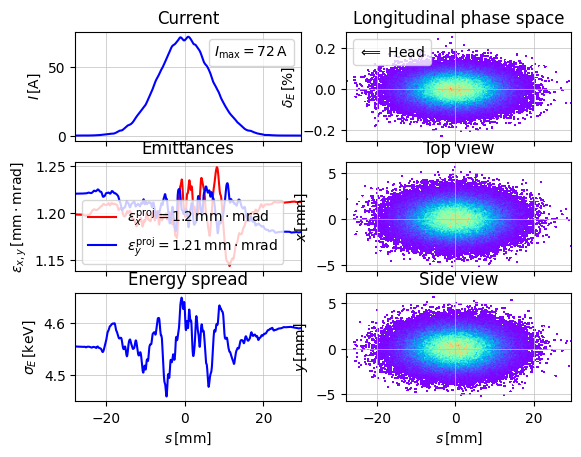

In [282]:
show_e_beam(p_array)

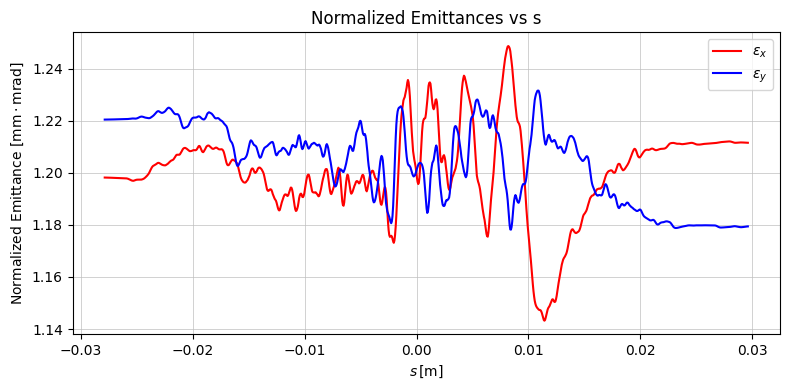

In [283]:
plot_emittances_vs_s(p_array)

s = 0.100 m, σ_τ = 6.682e-03 s
z = 0.1 / 239.41012539999994. Applied: HookProcesss = 0.200 m, σ_τ = 6.682e-03 s
z = 0.2 / 239.41012539999994. Applied: HookProcesss = 0.300 m, σ_τ = 6.682e-03 s
z = 0.30000000000000004 / 239.41012539999994. Applied: HookProcesss = 0.400 m, σ_τ = 6.682e-03 s
z = 0.4 / 239.41012539999994. Applied: HookProcesss = 0.500 m, σ_τ = 6.682e-03 s
z = 0.5 / 239.41012539999994. Applied: HookProcesss = 0.600 m, σ_τ = 6.682e-03 s
z = 0.6 / 239.41012539999994. Applied: HookProcesss = 0.700 m, σ_τ = 6.682e-03 s
z = 0.7 / 239.41012539999994. Applied: HookProcesss = 0.800 m, σ_τ = 6.682e-03 s
z = 0.7999999999999999 / 239.41012539999994. Applied: HookProcesss = 0.900 m, σ_τ = 6.682e-03 s
z = 0.8999999999999999 / 239.41012539999994. Applied: HookProcesss = 1.000 m, σ_τ = 6.682e-03 s
z = 0.9999999999999999 / 239.41012539999994. Applied: HookProcesss = 1.100 m, σ_τ = 6.682e-03 s
z = 1.0999999999999999 / 239.41012539999994. Applied: HookProcesss = 1.200 m, σ_τ = 6.682e-03 s
z 

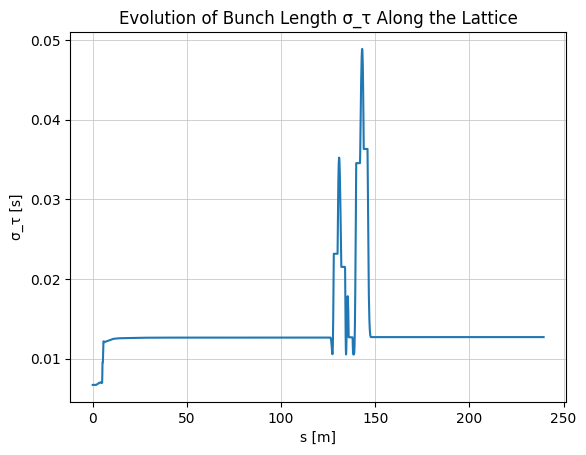

In [284]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Create the Navigator
navi = Navigator(lat)
navi.unit_step = 0.1  # high-resolution steps

# CSR example (optional)
# csr = CSR(n_bin=500, m_bin=5, sigma_min=.2e-6)
# navi.add_physics_proc(csr, csrm1_start, csrm1_end)

# Define the hook as a physics process
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# Attach the custom hook process
sigma_tau_list = []
hook_proc = HookProcess(sigma_tau_list)
navi.add_physics_proc(hook_proc, lat.sequence[0], lat.sequence[-1])

# Track
p_array_t = deepcopy(p_array)
start = time.time()
tws_track, p_array_t = track(lat, p_array_t, navi)
print("\n time exec:", time.time() - start, "sec")

# Plot
print("sigma_tau_list length:", len(sigma_tau_list))
print("lat.totalLen:", lat.totalLen)

s_axis = np.linspace(0, lat.totalLen, len(sigma_tau_list))
plt.plot(s_axis, sigma_tau_list)
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ Along the Lattice")
plt.grid(True)
plt.show()






In [285]:
sigma_tau = np.std(p_array.rparticles[4])
print("σ_τ before tracking:", sigma_tau, "s")

sigma_tau = np.std(p_array_t.rparticles[4])
print("σ_τ after tracking:", sigma_tau, "s")

σ_τ before tracking: 0.006681943745963765 s
σ_τ after tracking: 0.012690073965571038 s


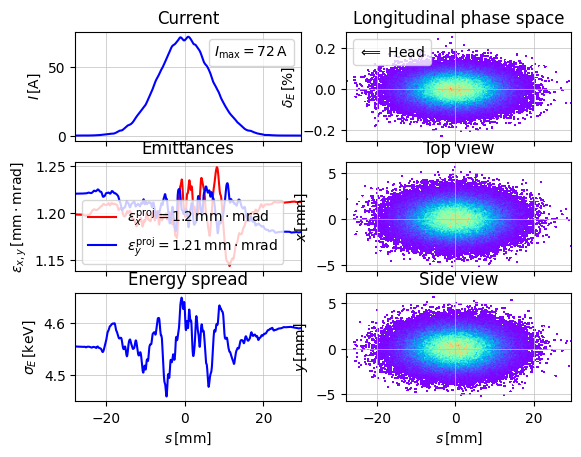

In [286]:
show_e_beam(p_array)

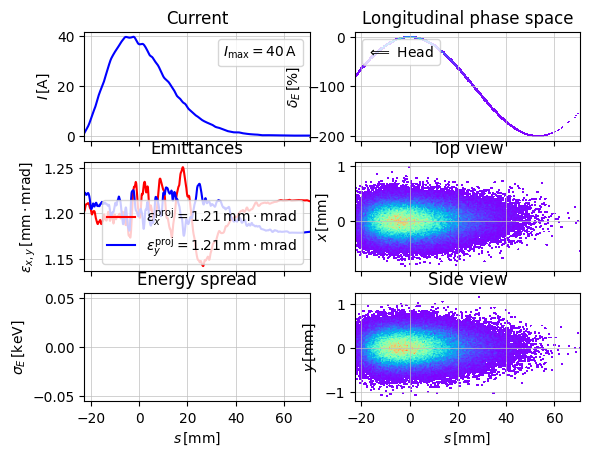

In [287]:
show_e_beam(p_array_t)

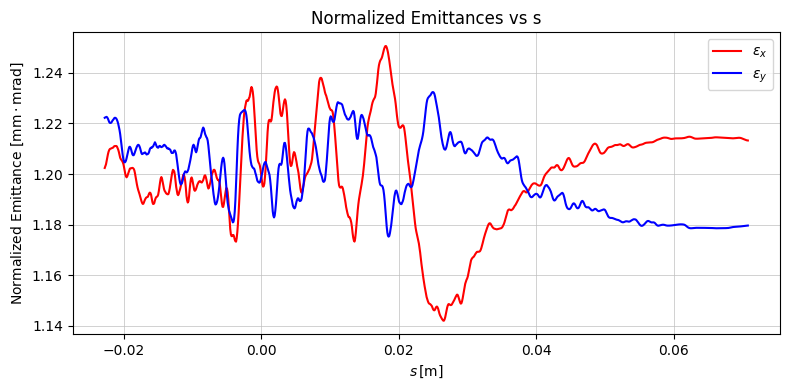

In [288]:
plot_emittances_vs_s(p_array_t)


In [289]:
import matplotlib.pyplot as plt
import numpy as np

def plot_energy_vs_position(tws_track):
    """
    Plot energy E as a function of position s from a list of Twiss-like objects.

    Parameters:
    tws_track (list): List of objects with attributes 's' (position) and 'E' (energy).
    """
    s = np.array([tw.s for tw in tws_track])
    E = np.array([tw.E for tw in tws_track])

    plt.figure(figsize=(10, 6))
    plt.plot(s, E, linewidth=2, marker='o', markersize=4)

    plt.title("Energy vs Position", fontsize=16)
    plt.xlabel("s (m)", fontsize=14)
    plt.ylabel("E (GeV)", fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()



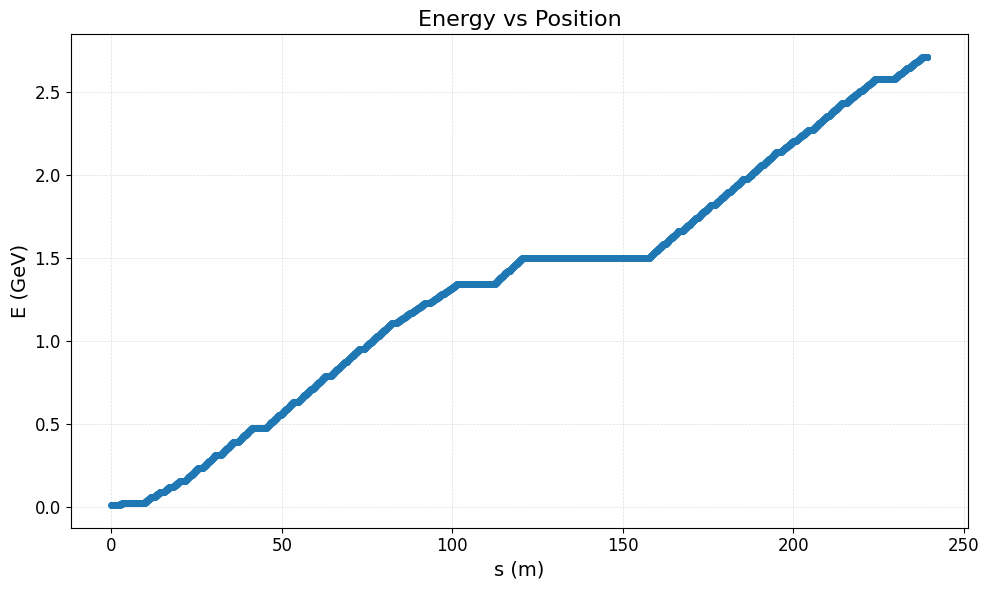

In [290]:
plot_energy_vs_position(tws_track)


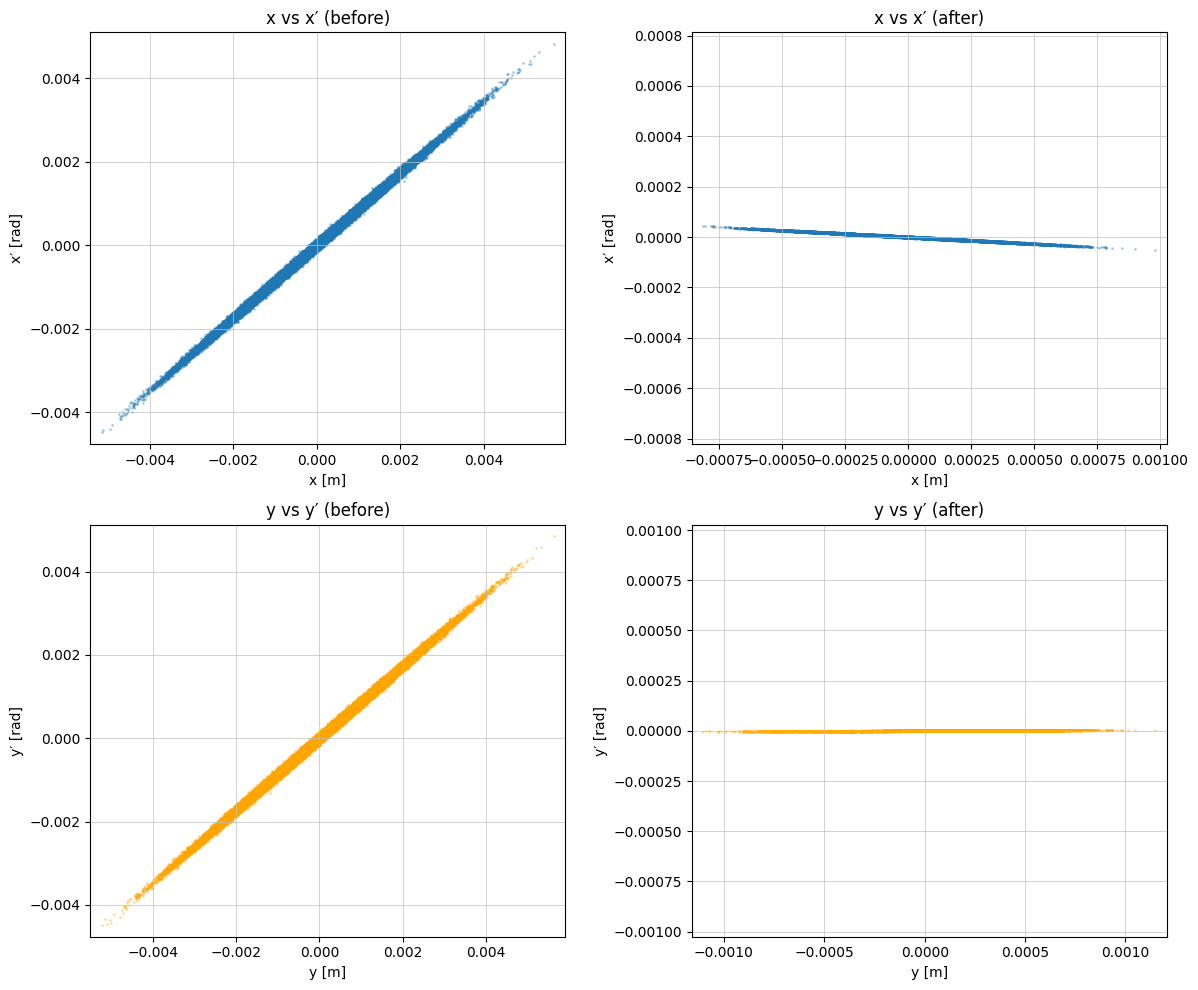

In [291]:
# --- After tracking: get final x, x', y, y' ---
x_t = p_array_t.rparticles[0]
xp_t = p_array_t.rparticles[1]
y_t = p_array_t.rparticles[2]
yp_t = p_array_t.rparticles[3]

# --- Plot initial vs final side-by-side ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# x-x′ before
axes[0][0].scatter(p_array.rparticles[0], p_array.rparticles[1], s=1, alpha=0.3)
axes[0][0].set_title("x vs x′ (before)")
axes[0][0].set_xlabel("x [m]")
axes[0][0].set_ylabel("x′ [rad]")
axes[0][0].grid(True)
axes[0][0].axis('equal')

# x-x′ after
axes[0][1].scatter(x_t, xp_t, s=1, alpha=0.3)
axes[0][1].set_title("x vs x′ (after)")
axes[0][1].set_xlabel("x [m]")
axes[0][1].set_ylabel("x′ [rad]")
axes[0][1].grid(True)
axes[0][1].axis('equal')

# y-y′ before
axes[1][0].scatter(p_array.rparticles[2], p_array.rparticles[3], s=1, alpha=0.3, color='orange')
axes[1][0].set_title("y vs y′ (before)")
axes[1][0].set_xlabel("y [m]")
axes[1][0].set_ylabel("y′ [rad]")
axes[1][0].grid(True)
axes[1][0].axis('equal')

# y-y′ after
axes[1][1].scatter(y_t, yp_t, s=1, alpha=0.3, color='orange')
axes[1][1].set_title("y vs y′ (after)")
axes[1][1].set_xlabel("y [m]")
axes[1][1].set_ylabel("y′ [rad]")
axes[1][1].grid(True)
axes[1][1].axis('equal')

plt.tight_layout()
plt.show()


In [292]:
import numpy as np

def compute_emittance(x, xp):
    x_mean = np.mean(x)
    xp_mean = np.mean(xp)

    x_cent = x - x_mean
    xp_cent = xp - xp_mean

    xx = np.mean(x_cent ** 2)
    xpxp = np.mean(xp_cent ** 2)
    xxp = np.mean(x_cent * xp_cent)

    emit = np.sqrt(xx * xpxp - xxp**2)
    return emit

# Final tracked coordinates
x, xp = p_array_t.rparticles[0], p_array_t.rparticles[1]
y, yp = p_array_t.rparticles[2], p_array_t.rparticles[3]

emit_x = compute_emittance(x, xp)
emit_y = compute_emittance(y, yp)

print(f"εₓ (RMS, final) = {emit_x:.5e} m·rad")
print(f"εᵧ (RMS, final) = {emit_y:.5e} m·rad")

emit_x0 = compute_emittance(p_array.rparticles[0], p_array.rparticles[1])
emit_y0 = compute_emittance(p_array.rparticles[2], p_array.rparticles[3])
print("Initial εₓ:", emit_x0)
print("Initial εᵧ:", emit_y0)

εₓ (RMS, final) = 2.28272e-10 m·rad
εᵧ (RMS, final) = 2.27456e-10 m·rad
Initial εₓ: 6.757033829017005e-08
Initial εᵧ: 6.771805922181499e-08


In [293]:
for tw in tws_track:
    print(f"s = {tw.s:.3f} m  |  beta_x = {tw.beta_x:.3f}  | beta_y = {tw.beta_y:.3f}  |  alpha_x = {tw.alpha_x:.3f} |  alpha_y = {tw.alpha_y:.3f}" )


s = 0.000 m  |  beta_x = 24.252  | beta_y = 24.521  |  alpha_x = -21.028 |  alpha_y = -21.249
s = 0.100 m  |  beta_x = 28.641  | beta_y = 28.956  |  alpha_x = -22.855 |  alpha_y = -23.095
s = 0.200 m  |  beta_x = 36.405  | beta_y = 30.890  |  alpha_x = -96.867 |  alpha_y = 40.071
s = 0.300 m  |  beta_x = 66.818  | beta_y = 18.647  |  alpha_x = -100.235 |  alpha_y = 32.769
s = 0.400 m  |  beta_x = 66.471  | beta_y = 17.588  |  alpha_x = 27.104 |  alpha_y = -1.355
s = 0.500 m  |  beta_x = 61.161  | beta_y = 17.861  |  alpha_x = 25.998 |  alpha_y = -1.371
s = 0.600 m  |  beta_x = 56.072  | beta_y = 18.137  |  alpha_x = 24.891 |  alpha_y = -1.387
s = 0.700 m  |  beta_x = 51.205  | beta_y = 18.416  |  alpha_x = 23.784 |  alpha_y = -1.403
s = 0.800 m  |  beta_x = 46.558  | beta_y = 18.698  |  alpha_x = 22.677 |  alpha_y = -1.419
s = 0.900 m  |  beta_x = 42.134  | beta_y = 18.983  |  alpha_x = 21.571 |  alpha_y = -1.435
s = 1.000 m  |  beta_x = 37.930  | beta_y = 19.272  |  alpha_x = 20.464 |

In [294]:
def get_energy_at_s(s_target, tws_list):
    s_array = np.array([tw.s for tw in tws_list])
    E_array = np.array([tw.E for tw in tws_list])
    return np.interp(s_target, s_array, E_array)


In [295]:
def plot_opt_func(lat, tws, top_plot=["Dx"], legend=True, fig_name=None, grid=True, font_size=12,
                  excld_legend=None, figsize=None, plt_figure=None):
    from ocelot.cpbd.optics import lattice_transfer_map

    if plt_figure is None:
        if fig_name is None:
            fig = plt.figure(figsize=figsize)
        else:
            fig = plt.figure(fig_name, figsize=figsize)
    else:
        fig = plt_figure

    plt.rc('axes', grid=grid)
    plt.rc('grid', color='0.75', linestyle='-', linewidth=0.5)
    left, width = 0.1, 0.85

    rect1 = [left, 0.65, width, 0.3]
    rect2 = [left, 0.19, width, 0.46]
    rect3 = [left, 0.07, width, 0.12]

    ax_top = fig.add_axes(rect1)
    ax_b = fig.add_axes(rect2, sharex=ax_top)
    ax_el = fig.add_axes(rect3, sharex=ax_top)

    for ax in ax_b, ax_el, ax_top:
        if ax != ax_el:
            for label in ax.get_xticklabels():
                label.set_visible(False)

    ax_b.grid(grid)
    ax_top.grid(grid)
    ax_el.set_yticks([])
    ax_el.grid(grid)

    fig.subplots_adjust(hspace=0)
    beta_x = [p.beta_x for p in tws]
    beta_y = [p.beta_y for p in tws]
    S = [p.s for p in tws]

    plt.xlim(S[0], S[-1])

    # Plot standard Twiss parameters
    plot_disp(ax_top, tws, [p for p in top_plot if p != "R56"], font_size)

    # ---- Add R56 Plotting ----
    if "R56" in top_plot:
        R56_vals = []
        s_vals = []

        for i in range(2, len(lat.sequence)):
            partial_lat = MagneticLattice(lat.sequence[:i])
            s_here = sum(e.l for e in partial_lat.sequence)

            try:
                E_here = get_energy_at_s(s_here, tws)
                R = lattice_transfer_map(partial_lat, energy=E_here)
                r56 = R[4, 5]
            except Exception as e:
                print(f"[WARN] Failed R56 at s = {s_here:.2f} m: {e}")
                r56 = 0

            # Debug print
            if i % 50 == 0 or s_here > 100:  # customize condition as you like
                print(f"s = {s_here:.2f} m, E = {E_here:.3f} GeV, R56 = {r56*1000:.3f} mm")

            R56_vals.append(r56)
            s_vals.append(s_here)

        
        ax_top.plot(s_vals, np.array(R56_vals), label="R56 [m]", color="red", linewidth=2)

    if "R56" in top_plot or legend:
        ax_top.legend(fontsize=font_size - 2)

    # Plot betas and elements
    plot_betas(ax_b, S, beta_x, beta_y, font_size)
    plot_elems(fig, ax_el, lat, s_point=S[0], legend=legend, y_scale=0.8, font_size=font_size,
               excld_legend=excld_legend)


s = 5.14 m, E = 0.025 GeV, R56 = -0.935 mm
s = 10.25 m, E = 0.034 GeV, R56 = -17.541 mm
s = 17.31 m, E = 0.122 GeV, R56 = -21.131 mm
s = 22.11 m, E = 0.166 GeV, R56 = -21.716 mm
s = 30.72 m, E = 0.313 GeV, R56 = -22.551 mm
s = 36.96 m, E = 0.393 GeV, R56 = -22.757 mm
s = 45.19 m, E = 0.472 GeV, R56 = -22.897 mm
s = 54.47 m, E = 0.631 GeV, R56 = -23.074 mm
s = 63.76 m, E = 0.789 GeV, R56 = -23.182 mm
s = 72.97 m, E = 0.948 GeV, R56 = -23.255 mm
s = 82.32 m, E = 1.107 GeV, R56 = -23.307 mm
s = 89.99 m, E = 1.194 GeV, R56 = -23.330 mm
s = 99.44 m, E = 1.311 GeV, R56 = -23.356 mm
s = 101.48 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.48 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.52 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.57 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.62 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.62 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.77 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.77 m, E = 1.341 GeV, R56 = -23.362 mm
s = 101.91 m, E = 1.341 GeV, R56 = -23.362 mm
s =

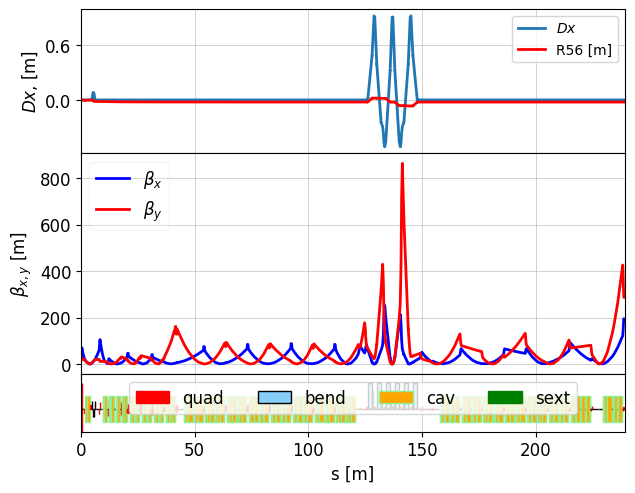

In [296]:
plot_opt_func(lat, tws, top_plot=["Dx", "R56"], legend=True )

In [297]:
# Your element IDs
start_id = "PA1RFGUN"
end_id   = "L491"

# Find their indices in the lattice
start_index = next(i for i, el in enumerate(lattice_list) if el.id == start_id)
end_index   = next(i for i, el in enumerate(lattice_list) if el.id == end_id)

# Create the sub-lattice
partial_lat = MagneticLattice(lattice_list[start_index:end_index + 1])

# Get s-positions of those indices
s_start = sum(el.l for el in lattice_list[:start_index])
s_end   = sum(el.l for el in lattice_list[:end_index + 1])
s_mid   = 0.5 * (s_start + s_end)

# Interpolate energy at midpoint
E_here = get_energy_at_s(s_mid, tws)

# Calculate R56
R = lattice_transfer_map(partial_lat, energy=E_here)
r56 = R[4, 5]

# Print result
print(f"R56 from '{start_id}' to '{end_id}' (s = {s_start:.2f} to {s_end:.2f} m, E ≈ {E_here:.3f} GeV): R56 = {r56*1000:.3f} mm")

R56 from 'PA1RFGUN' to 'L491' (s = 0.00 to 45.01 m, E ≈ 0.175 GeV): R56 = -21.806 mm


In [298]:
def compute_r56_with_energy_evolution(lat_list, tws, id_start, id_end):
    # Find element indices
    i_start = next(i for i, el in enumerate(lat_list) if el.id == id_start)
    i_end   = next(i for i, el in enumerate(lat_list) if el.id == id_end)

    # Build the sub-lattice
    partial_lat = MagneticLattice(lat_list[i_start:i_end + 1])

    # Use starting energy from Twiss at i_start
    s_start = sum(e.l for e in lat_list[:i_start])
    E_start = get_energy_at_s(s_start, tws)

    # Compute transfer maps at every step (tracks energy changes!)
    Bs, Rs, Ts, Ss = partial_lat.transfer_maps(energy=E_start, output_at_each_step=True)

    # Get the last transfer matrix — full map from PJARCM1 to PSECTC
    R_final = Rs[-1]
    r56 = R_final[4, 5]

    s_end = s_start + sum(e.l for e in lat_list[i_start:i_end + 1])
    print(f"R56 from '{id_start}' to '{id_end}' (s = {s_start:.2f} → {s_end:.2f} m): R56 = {r56*1000:.3f} mm")


In [299]:
compute_r56_with_energy_evolution(lattice_list, tws, "PA1RFGUN", "L491")


R56 from 'PA1RFGUN' to 'L491' (s = 0.00 → 45.01 m): R56 = -22.795 mm


In [300]:
final_twiss = tws_track[-1]

print("\n===== Final Beam Parameters =====")
print(f"Position s (m):       {final_twiss.s:.4f}")
print(f"Energy E (GeV):       {final_twiss.E:.6f}")
print(f"Beta X (βx) (m):      {final_twiss.beta_x:.6f}")
print(f"Beta Y (βy) (m):      {final_twiss.beta_y:.6f}")
print(f"Alpha X (αx):         {final_twiss.alpha_x:.6f}")
print(f"Alpha Y (αy):         {final_twiss.alpha_y:.6f}")
print(f"Norm. Emit X (m.rad): {final_twiss.emit_xn:.6e}")
print(f"Norm. Emit Y (m.rad): {final_twiss.emit_yn:.6e}")
print(f"Geom. Emit X (m.rad): {final_twiss.emit_x:.6e}")
print(f"Geom. Emit Y (m.rad): {final_twiss.emit_y:.6e}")



===== Final Beam Parameters =====
Position s (m):       239.4101
Energy E (GeV):       2.709241
Beta X (βx) (m):      182.784982
Beta Y (βy) (m):      288.779269
Alpha X (αx):         9.744906
Alpha Y (αy):         -0.970697
Norm. Emit X (m.rad): 1.210266e-06
Norm. Emit Y (m.rad): 1.205941e-06
Geom. Emit X (m.rad): 2.282723e-10
Geom. Emit Y (m.rad): 2.274564e-10


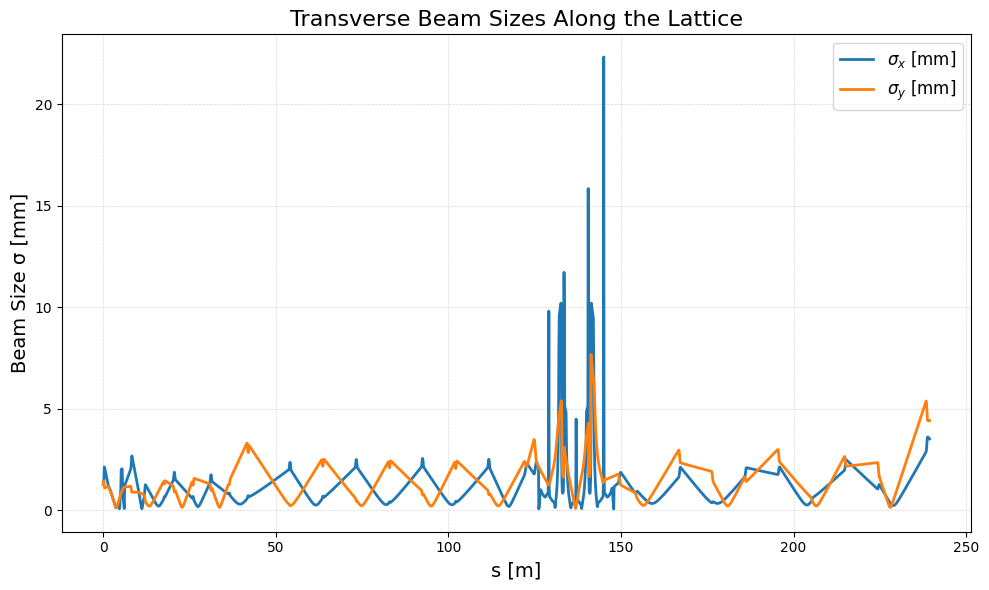

In [301]:
import numpy as np
import matplotlib.pyplot as plt

# Extract position and beta functions
s = np.array([tw.s for tw in tws_track])
beta_x = np.array([tw.beta_x for tw in tws_track])
beta_y = np.array([tw.beta_y for tw in tws_track])

# Use initial geometric emittances
emit_x = tw0.emit_x
emit_y = tw0.emit_y

# Compute beam sizes σx and σy in meters
sigma_x = np.sqrt(beta_x * emit_x)
sigma_y = np.sqrt(beta_y * emit_y)

# Plot beam sizes in millimeters
plt.figure(figsize=(10, 6))
plt.plot(s, sigma_x * 1e3, label=r'$\sigma_x$ [mm]', linewidth=2)
plt.plot(s, sigma_y * 1e3, label=r'$\sigma_y$ [mm]', linewidth=2)

plt.xlabel('s [m]', fontsize=14)
plt.ylabel('Beam Size σ [mm]', fontsize=14)
plt.title('Transverse Beam Sizes Along the Lattice', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
